# Columna vertical que se dobla bajo su propio peso: solución por diferencias finitas

Este notebook muestra un ejemplo didáctico para estudiantes de **Métodos Numéricos**: una **columna vertical en voladizo** (empotrada en la base y libre en el extremo superior) que pierde estabilidad por efecto de su **propio peso distribuido**.

A diferencia del problema clásico de Euler con una carga axial constante aplicada en el extremo, aquí la fuerza axial interna **varía con la altura** porque cada sección sostiene únicamente el peso de la parte de columna que tiene por encima.

---

## Imágenes representativas del fenómeno

**1) Aparato experimental de pandeo de columnas**  
![Aparato experimental de pandeo](buckledmodel.jpg)

**2) Árbol como ejemplo natural de estructura esbelta limitada por peso propio**  
![Árbol como ejemplo natural de estabilidad estructural](Self-buckling.png)

**Créditos de imágenes**  
- `buckledmodel.jpg`: Wikimedia Commons, *Buckledmodel.JPG*  
- `tree.jpg`: Wikimedia Commons, *Acer pseudoplatanus Chaltenbrunnen.jpg*

---

## 1. Modelo físico

Sea $x$ la coordenada vertical medida desde la **base** ($x=0$) hasta la **punta** ($x=L$).  
Sea $w$ el peso por unidad de longitud de la columna:

$w = \rho g A$

donde:

- $\rho$ es la densidad,
- $g$ es la gravedad,
- $A$ es el área de la sección transversal.

La fuerza axial interna en una sección ubicada en $x$ vale el peso del tramo situado por encima:

$P(x) = w(L-x)$

Para pequeñas rotaciones, el problema linealizado de estabilidad puede escribirse en términos del ángulo de giro $\theta(x)$ como:

$EI\,\dfrac{d^2\theta}{dx^2} + P(x)\,\theta = 0$

es decir,

$EI\,\dfrac{d^2\theta}{dx^2} + w(L-x)\,\theta = 0$

donde $E$ es el módulo de Young e $I$ es el segundo momento de área.

---

## 2. Condiciones de frontera

Como la columna está **empotrada en la base** y **libre en la punta**, usamos:

- en la base: $\theta(0)=0$,
- en la punta libre: $\dfrac{d\theta}{dx}(L)=0$.

La segunda condición representa momento nulo en el extremo libre dentro de esta formulación linealizada.

---

## 3. Forma adimensional

Definimos la coordenada adimensional:

$\xi = \dfrac{x}{L}$

Entonces:

$\dfrac{d}{dx} = \dfrac{1}{L}\dfrac{d}{d\xi}, \qquad
\dfrac{d^2}{dx^2} = \dfrac{1}{L^2}\dfrac{d^2}{d\xi^2}$

Sustituyendo en la ecuación diferencial:

$\dfrac{d^2\theta}{d\xi^2} + \beta(1-\xi)\theta = 0$

con

$\beta = \dfrac{wL^3}{EI}$

El valor crítico de $\beta$ determina el inicio del pandeo por peso propio.

---

## 4. Discretización por diferencias finitas

Dividimos el intervalo $0 \le \xi \le 1$ en $N$ nodos uniformes con paso:

$h = \dfrac{1}{N-1}$

La derivada segunda en un nodo interior $\xi_i$ se aproxima mediante la fórmula centrada:

$\dfrac{d^2\theta}{d\xi^2}(\xi_i)
\approx
\dfrac{\theta_{i+1}-2\theta_i+\theta_{i-1}}{h^2}$

Por tanto, la ecuación discreta queda:

$\dfrac{\theta_{i+1}-2\theta_i+\theta_{i-1}}{h^2} + \beta(1-\xi_i)\theta_i = 0$

o equivalentemente,

$\theta_{i+1}
=
2\theta_i - \theta_{i-1} - h^2\beta(1-\xi_i)\theta_i$

---

## 5. Estrategia numérica

Para evitar la solución trivial $\theta \equiv 0$, imponemos una normalización artificial en la base:

$\theta(0)=0, \qquad \theta'(0)=1$

En diferencias finitas, esto se aproxima como:

$\theta_0 = 0, \qquad \theta_1 = h$

Con esto, para un valor dado de $\beta$, la recurrencia permite construir toda la solución.  
Luego evaluamos el residuo de la condición de punta libre:

$R(\beta) = \dfrac{\theta_{N-1}-\theta_{N-2}}{h}$

El valor crítico se obtiene resolviendo numéricamente:

$R(\beta)=0$

---

## 6. Recuperación de la deflexión lateral

Una vez calculado $\theta(\xi)$, la deflexión lateral adimensional $y(\xi)$ se obtiene integrando:

$\dfrac{dy}{d\xi} = \theta(\xi)$

de donde:

$y(\xi) = \int_0^{\xi} \theta(s)\,ds$

Numéricamente, esta integral se calcula con una suma acumulada tipo trapecio.

---

## 7. Comentario analítico importante

Este problema corresponde al clásico problema de **Greenhill** para una columna pesada.  
La solución exacta ya no es tan simple como en el caso de Euler con carga axial constante.  
En la literatura clásica, la solución para la columna uniforme bajo peso propio suele aparecer en términos de **funciones especiales**; según la formulación empleada puede expresarse mediante **funciones de Bessel** y también aparecen formulaciones equivalentes relacionadas con **funciones de Airy** en problemas de columnas pesadas más generales.

Para una columna uniforme en voladizo, el valor crítico clásico es aproximadamente:

$\beta_{cr} \approx 7.8373$

es decir,

$\dfrac{wL_{cr}^3}{EI} \approx 7.8373$

de donde:

$L_{cr} \approx \left(\dfrac{7.8373\,EI}{w}\right)^{1/3}$

---

## 8. Qué hará el código

El código en la única celda siguiente:

1. define las propiedades de una lámina delgada vertical,  
2. calcula el valor crítico numérico de $\beta$,  
3. compara con el valor clásico de Greenhill,  
4. obtiene la forma de giro $\theta(\xi)$ y la deflexión lateral $y(\xi)$,  
5. genera gráficas ilustrativas.


COLUMNA QUE SE DOBLA BAJO SU PROPIO PESO
E                 = 3.0000e+09 Pa
rho               = 1200.0000 kg/m^3
A                 = 1.600000e-05 m^2
I                 = 8.533333e-13 m^4
w = rho*g*A       = 1.883520e-01 N/m
----------------------------------------------------------------------
beta_cr numérico  = 7.837352
beta_cr Greenhill = 7.837300
Error relativo beta (%) = 0.0007
----------------------------------------------------------------------
L_cr numérico     = 0.474038 m
L_cr Greenhill    = 0.474037 m
Error relativo L (%) = 0.0002


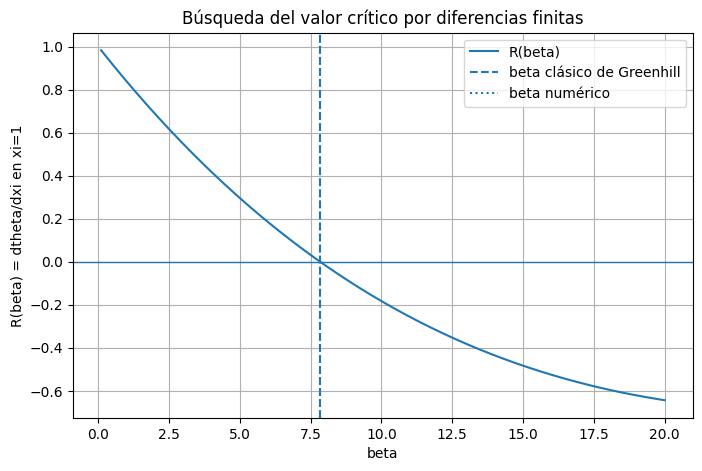

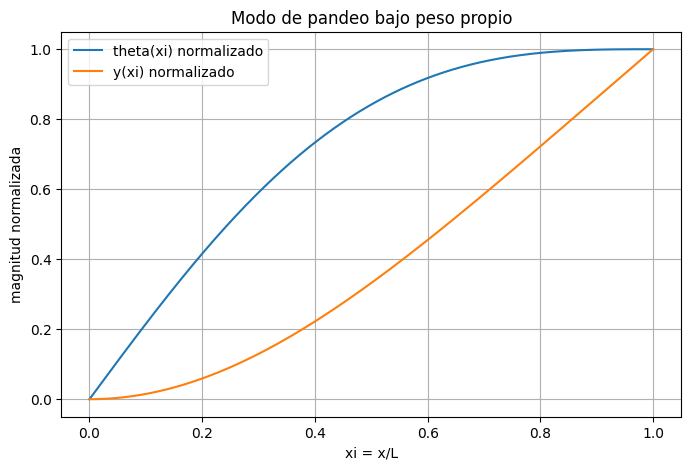

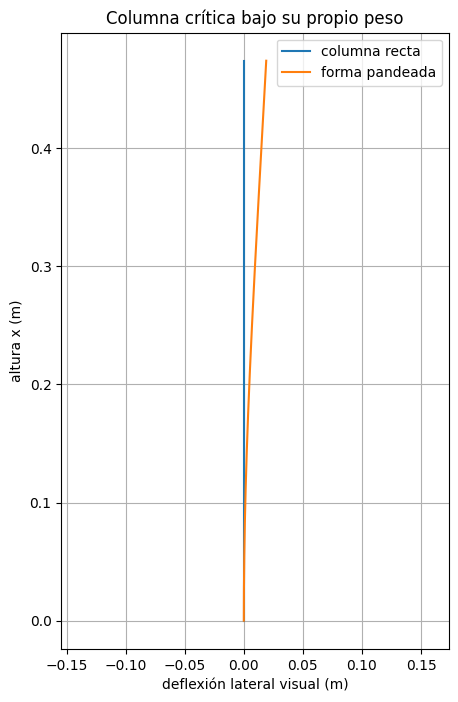

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ============================================================
# 1) DATOS DEL PROBLEMA
#    Ejemplo: lámina delgada de polímero/acrílico flexible
# ============================================================
E = 3.0e9          # Pa
rho = 1200.0       # kg/m^3
g = 9.81           # m/s^2
b = 0.020          # m   (ancho)
t = 0.0008         # m   (espesor)

A = b * t
I = b * t**3 / 12.0
w = rho * g * A    # peso por unidad de longitud, N/m

# Valor clásico de Greenhill para una columna uniforme empotrada-libre
beta_greenhill = 7.8373

# Longitud crítica analítica aproximada
L_crit_greenhill = (beta_greenhill * E * I / w)**(1.0/3.0)

# Para ilustrar la forma pandeada, usamos precisamente la longitud crítica analítica
L = L_crit_greenhill

# ============================================================
# 2) MALLA ADIMENSIONAL Y RECURRENCIA EN DIFERENCIAS FINITAS
# ============================================================
N = 400
xi = np.linspace(0.0, 1.0, N)
h = xi[1] - xi[0]

def solve_theta(beta, N=400):
    xi = np.linspace(0.0, 1.0, N)
    h = xi[1] - xi[0]
    theta = np.zeros(N)

    # Normalización artificial:
    # theta(0)=0 y theta'(0)=1  => theta_1 ~ h
    theta[0] = 0.0
    theta[1] = h

    # Recurrencia de diferencias finitas
    for i in range(1, N-1):
        theta[i+1] = 2.0*theta[i] - theta[i-1] - h**2 * beta * (1.0 - xi[i]) * theta[i]

    # Residuo de la condición en la punta libre: theta'(1)=0
    residual = (theta[-1] - theta[-2]) / h
    return xi, theta, residual

def residual_beta(beta):
    _, _, R = solve_theta(beta, N=N)
    return R

# ============================================================
# 3) BÚSQUEDA DEL VALOR CRÍTICO beta
# ============================================================
# Exploración para hallar un intervalo con cambio de signo
beta_scan = np.linspace(0.1, 20.0, 800)
R_scan = np.array([residual_beta(bet) for bet in beta_scan])

beta_left = None
beta_right = None
for i in range(len(beta_scan)-1):
    if R_scan[i] == 0:
        beta_left = beta_scan[i]
        beta_right = beta_scan[i]
        break
    if R_scan[i] * R_scan[i+1] < 0:
        beta_left = beta_scan[i]
        beta_right = beta_scan[i+1]
        break

if beta_left is None:
    raise RuntimeError("No se encontró un intervalo con cambio de signo para R(beta).")

if beta_left == beta_right:
    beta_cr_num = beta_left
else:
    beta_cr_num = brentq(residual_beta, beta_left, beta_right)

xi, theta_cr, Rcr = solve_theta(beta_cr_num, N=N)

# ============================================================
# 4) DEFLEXIÓN LATERAL ADIMENSIONAL y(xi)
#    dy/dxi = theta
# ============================================================
y = np.zeros_like(theta_cr)
for i in range(1, len(y)):
    y[i] = y[i-1] + 0.5 * (theta_cr[i] + theta_cr[i-1]) * h

# Escalamiento visual solamente
theta_plot = theta_cr / np.max(np.abs(theta_cr))
y_plot = y / np.max(np.abs(y))

# ============================================================
# 5) MAGNITUDES CRÍTICAS
# ============================================================
L_crit_num = (beta_cr_num * E * I / w)**(1.0/3.0)
error_beta = abs(beta_cr_num - beta_greenhill) / beta_greenhill * 100.0
error_L = abs(L_crit_num - L_crit_greenhill) / L_crit_greenhill * 100.0

print("="*70)
print("COLUMNA QUE SE DOBLA BAJO SU PROPIO PESO")
print("="*70)
print(f"E                 = {E:.4e} Pa")
print(f"rho               = {rho:.4f} kg/m^3")
print(f"A                 = {A:.6e} m^2")
print(f"I                 = {I:.6e} m^4")
print(f"w = rho*g*A       = {w:.6e} N/m")
print("-"*70)
print(f"beta_cr numérico  = {beta_cr_num:.6f}")
print(f"beta_cr Greenhill = {beta_greenhill:.6f}")
print(f"Error relativo beta (%) = {error_beta:.4f}")
print("-"*70)
print(f"L_cr numérico     = {L_crit_num:.6f} m")
print(f"L_cr Greenhill    = {L_crit_greenhill:.6f} m")
print(f"Error relativo L (%) = {error_L:.4f}")
print("="*70)

# ============================================================
# 6) GRÁFICAS
# ============================================================

# Residuo R(beta)
plt.figure(figsize=(8,5))
plt.plot(beta_scan, R_scan, label='R(beta)')
plt.axhline(0.0, linewidth=1.0)
plt.axvline(beta_greenhill, linestyle='--', label='beta clásico de Greenhill')
plt.axvline(beta_cr_num, linestyle=':', label='beta numérico')
plt.xlabel('beta')
plt.ylabel('R(beta) = dtheta/dxi en xi=1')
plt.title('Búsqueda del valor crítico por diferencias finitas')
plt.legend()
plt.grid(True)
plt.show()

# Giro y deflexión adimensional
plt.figure(figsize=(8,5))
plt.plot(xi, theta_plot, label='theta(xi) normalizado')
plt.plot(xi, y_plot, label='y(xi) normalizado')
plt.xlabel('xi = x/L')
plt.ylabel('magnitud normalizada')
plt.title('Modo de pandeo bajo peso propio')
plt.legend()
plt.grid(True)
plt.show()

# Forma deformada visual de la columna
plt.figure(figsize=(5,8))
x_vertical = xi * L_crit_num
amp = 0.04 * L_crit_num  # amplitud visual arbitraria
x_def = amp * y_plot
plt.plot(np.zeros_like(x_vertical), x_vertical, label='columna recta')
plt.plot(x_def, x_vertical, label='forma pandeada')
plt.xlabel('deflexión lateral visual (m)')
plt.ylabel('altura x (m)')
plt.title('Columna crítica bajo su propio peso')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


## 9. Observaciones didácticas

- En el problema de Euler clásico, la carga axial es constante y la solución involucra funciones trigonométricas.
- En la columna bajo peso propio, la fuerza axial depende de la posición, por lo que el problema cambia de naturaleza.
- Aquí usamos una **aproximación por diferencias finitas** y una **búsqueda de raíz** para localizar el valor crítico.
- Este ejemplo muestra muy bien cómo un problema de estabilidad estructural puede convertirse en un problema numérico de frontera con parámetro.

## 10. Posibles extensiones para clase o tarea

1. Cambiar la geometría de la sección transversal y estudiar el efecto sobre $I$ y $L_{cr}$.  
2. Comparar distintos materiales: acero, aluminio, madera, polímeros.  
3. Estudiar una columna cónica o no uniforme.  
4. Incluir una pequeña imperfección geométrica inicial y resolver el problema poscrítico aproximado.  
5. Comparar el método de diferencias finitas con disparo (shooting) usando `solve_ivp`.

---
**Fin del notebook**
